In [5]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")


In [6]:
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Insights
Glucose (mg/dL): 40 – 200

Blood Pressure (mmHg): 40 – 120

Skin Thickness (mm): 10 – 99

Insulin (µU/mL): 15 – 900

BMI (kg/m²): 10 – 70

Diabetes Pedigree Function: 0.078 – 2.5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

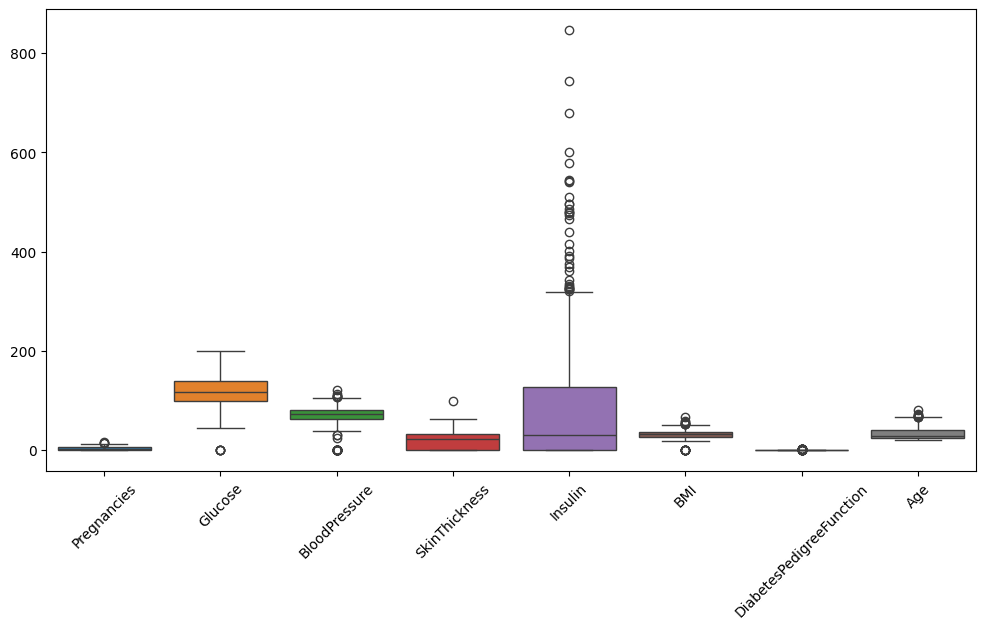

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop(columns=["Outcome"]))
plt.xticks(rotation=45)
plt.show()



In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Keep non-outliers
df_no_outliers = df[~((df < lower) | (df > upper)).any(axis=1)]


In [12]:
for col in df.columns[:-1]:
    df[col] = df[col].clip(lower[col], upper[col])


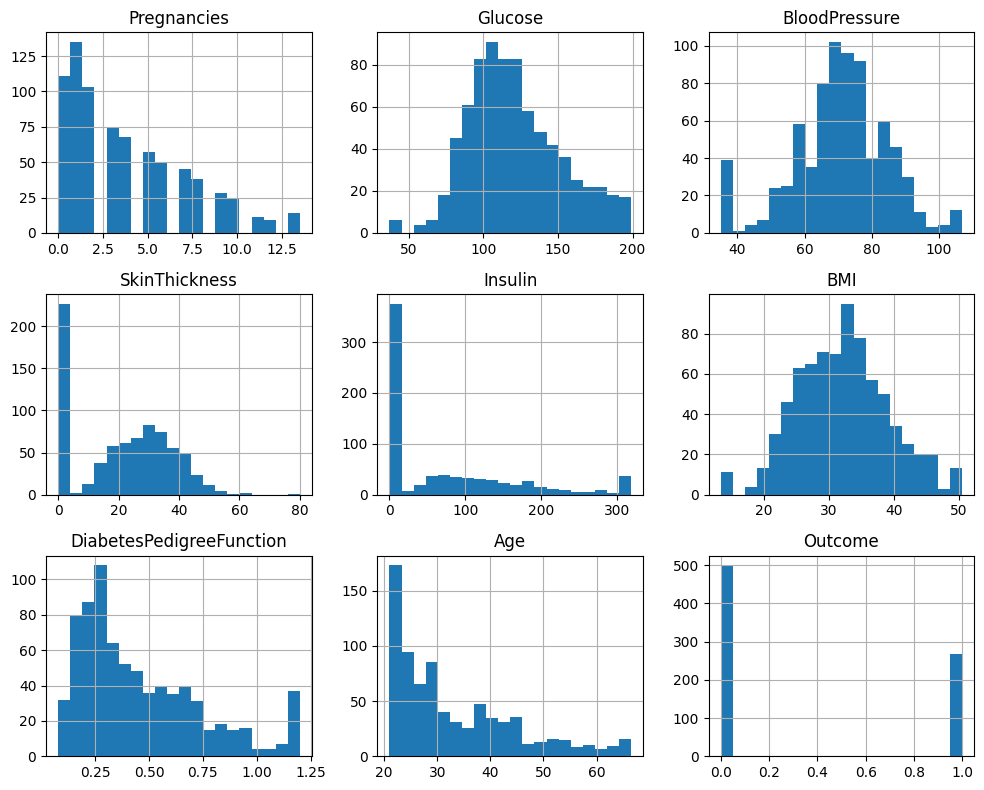

In [13]:
df.hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()


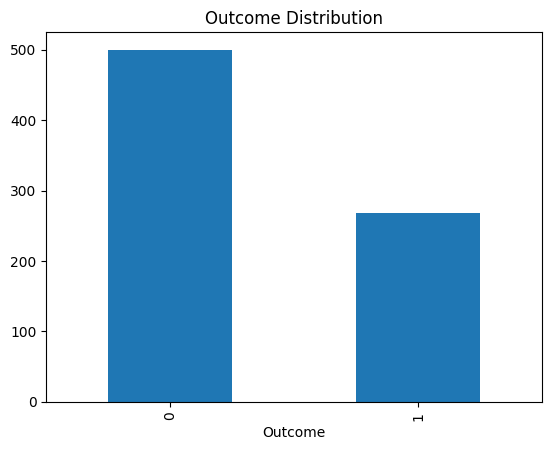

In [14]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Outcome Distribution")
plt.show()


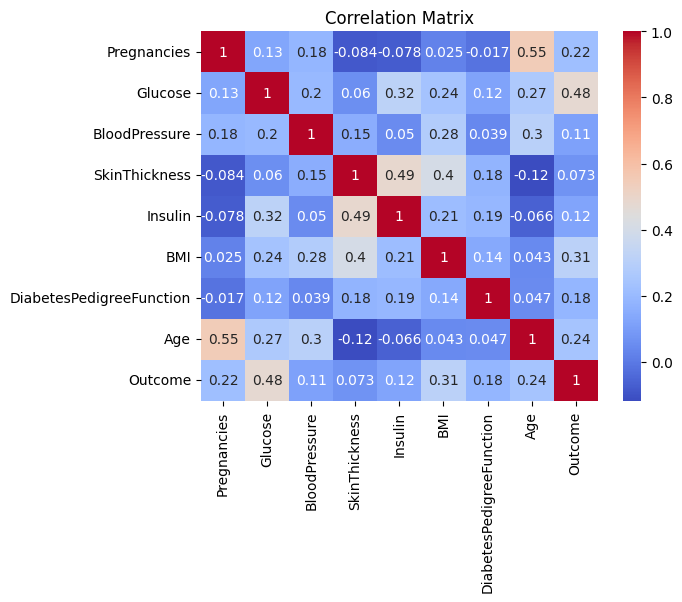

In [15]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [16]:
df["Glucose"]=df["Glucose"].replace(0,df["Glucose"].median())
df["Glucose"].min()

np.float64(37.125)

In [17]:
for col in df.columns:
    df[col]=df[col].replace(0,df[col].median())
    print(df[col].name,df[col].min())


Pregnancies 1.0
Glucose 37.125
BloodPressure 35
SkinThickness 7
Insulin 14.0
BMI 13.35
DiabetesPedigreeFunction 0.078
Age 21.0
Outcome 0


In [18]:
import matplotlib.pyplot as plt


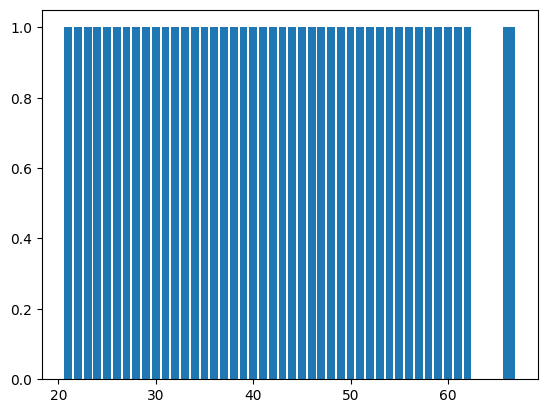

In [19]:
plt.bar(df["Age"],df["Outcome"])
plt.show()

In [20]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.135000
1    37.052239
Name: Age, dtype: float64

In [21]:
df.groupby("Outcome")["Age"].std()

Outcome
0    11.477227
1    10.925826
Name: Age, dtype: float64

In [22]:
df["Age"].groupby(df["Outcome"]).std()

Outcome
0    11.477227
1    10.925826
Name: Age, dtype: float64

In [23]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='Outcome'>

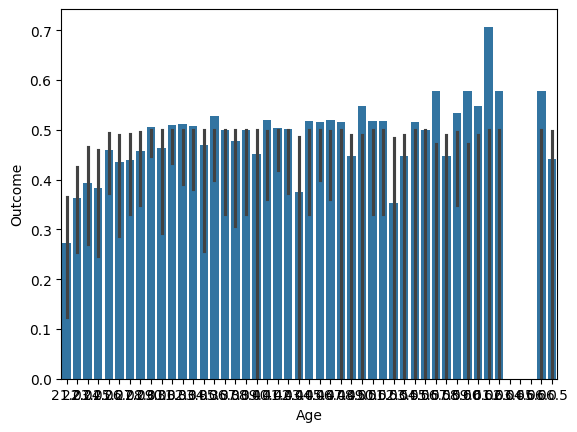

In [24]:
sns.barplot(x=df["Age"],y=df["Outcome"],estimator="std")

<Axes: xlabel='Age'>

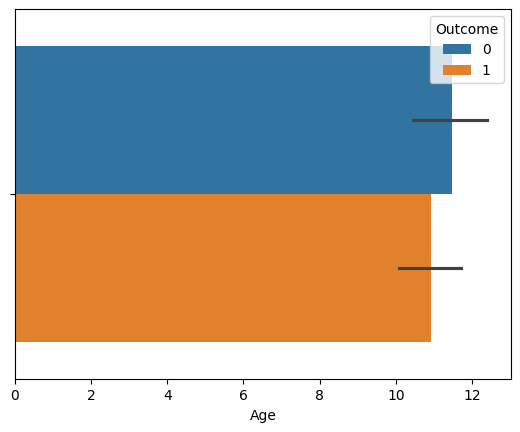

In [25]:
sns.barplot(x=df["Age"],hue=df["Outcome"],estimator="std")

<Axes: xlabel='Age', ylabel='Count'>

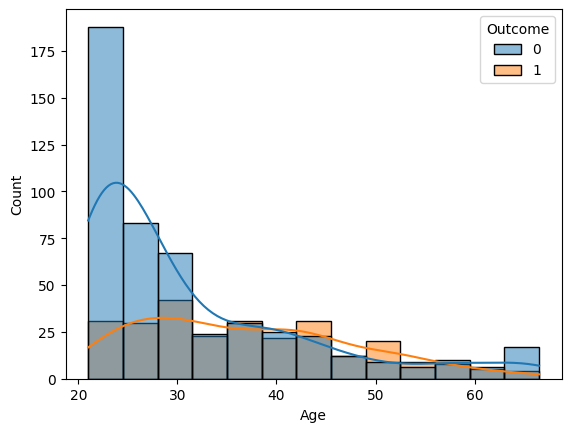

In [26]:
sns.histplot(x=df["Age"],hue=df["Outcome"],data=df,kde=True)



In [27]:
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

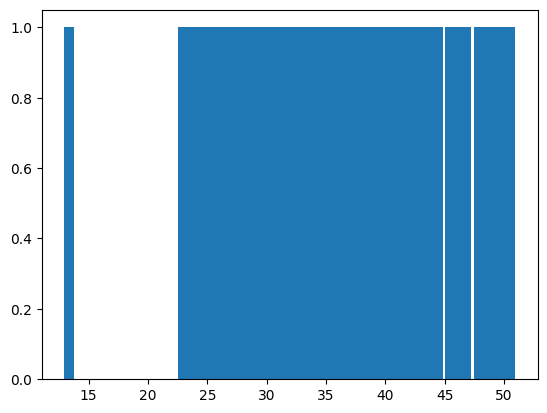

In [28]:
plt.bar(df["BMI"],df["Outcome"])
plt.show()

In [29]:
df.groupby("Outcome")["BMI"].mean()

Outcome
0    30.527500
1    35.105597
Name: BMI, dtype: float64

In [30]:
df.groupby("Outcome")["BMI"].std()

Outcome
0    6.849655
1    6.432723
Name: BMI, dtype: float64

In [31]:
import numpy as np

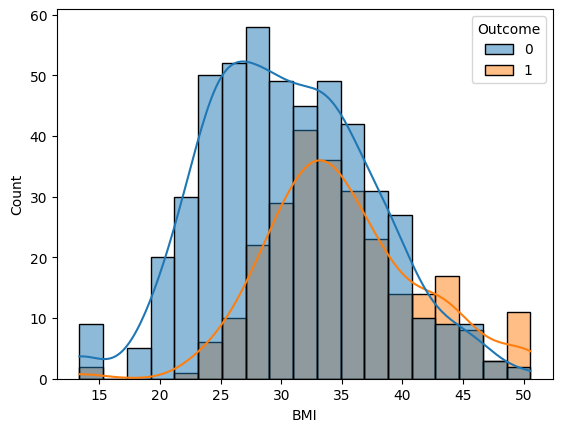

In [32]:
sns.histplot(x=df["BMI"],hue=df["Outcome"],data=df,kde=True)
plt.show()


In [33]:
df.BMI.value_counts()

BMI
32.00    13
31.60    12
31.20    12
13.35    11
32.40    10
         ..
49.60     1
24.10     1
41.20     1
49.30     1
46.30     1
Name: count, Length: 242, dtype: int64

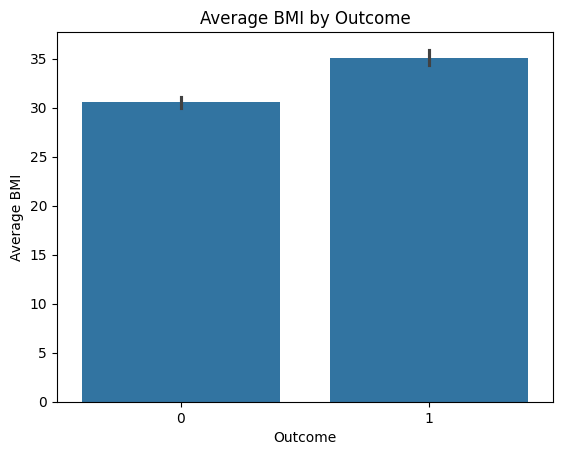

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.barplot(data=df, x='Outcome', y='BMI', estimator=np.mean)
plt.title("Average BMI by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average BMI")
plt.show()


In [35]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [36]:
die_age=df["Age"][df["Outcome"]==1]
nondie_age=df["Age"][df["Outcome"]==0]
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_age,nondie_age)
alpha=0.05
if p<alpha:
    print("Reject H0")
else:
    print("Accept H0")


Reject H0


In [37]:
die_age=df["BMI"][df["Outcome"]==1]
nondie_age=df["BMI"][df["Outcome"]==0]
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_age,nondie_age)
alpha=0.05
if p<alpha:
    print("Reject H0")
else:
    print("Accept H0")

Reject H0


Outcome
0    69.508000
1    72.880597
Name: BloodPressure, dtype: float64


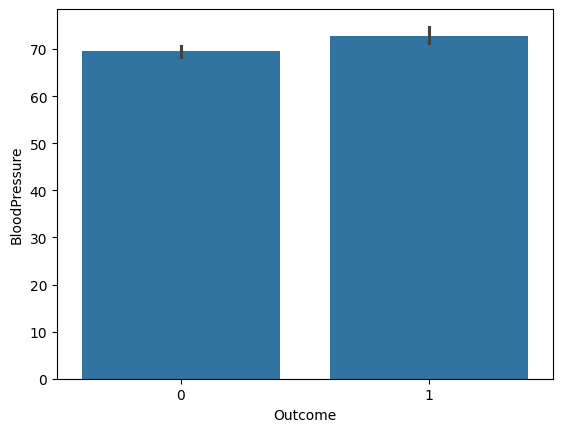

Outcome
0    13.549210
1    15.115805
Name: BloodPressure, dtype: float64


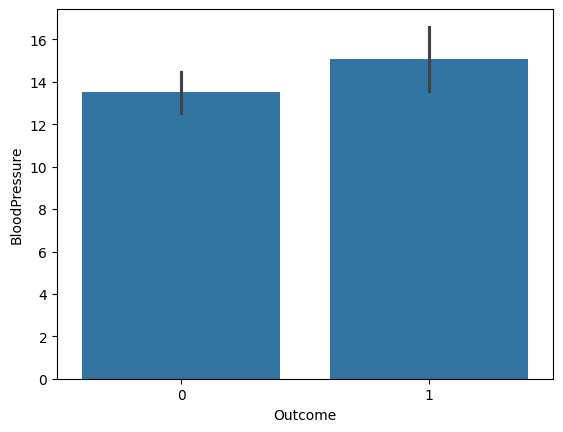

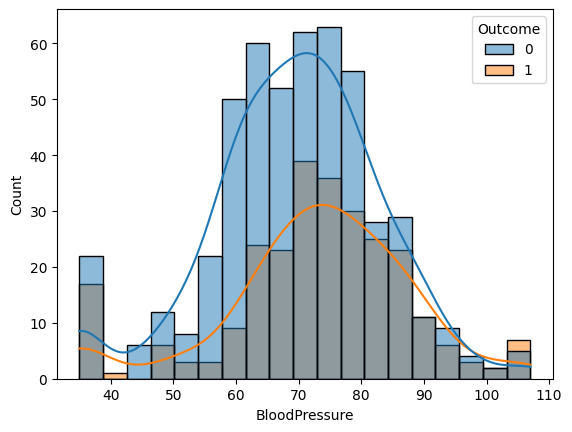

In [38]:
gr=df.groupby("Outcome")["BloodPressure"].mean()
print(gr)
sns.barplot(x=df["Outcome"],y=df["BloodPressure"],estimator=np.mean)
plt.show()
gr1=df.groupby("Outcome")["BloodPressure"].std()
print(gr1)
sns.barplot(x=df["Outcome"],y=df["BloodPressure"],estimator=np.std)
plt.show()
sns.histplot(x=df["BloodPressure"],hue=df["Outcome"],data=df,kde=True)
plt.show()

In [39]:
die_age=df["BloodPressure"][df["Outcome"]==1]
nondie_age=df["BloodPressure"][df["Outcome"]==0]
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_age,nondie_age)
alpha=0.05
if p<alpha:
    print("Reject H0")
else:
    print("Accept H0")

Reject H0


h0-both groups similar
h1-            not similar
Rejecting h0 means both groups are not similar,therefore many differences are there

Outcome
0    69.508000
1    72.880597
Name: BloodPressure, dtype: float64


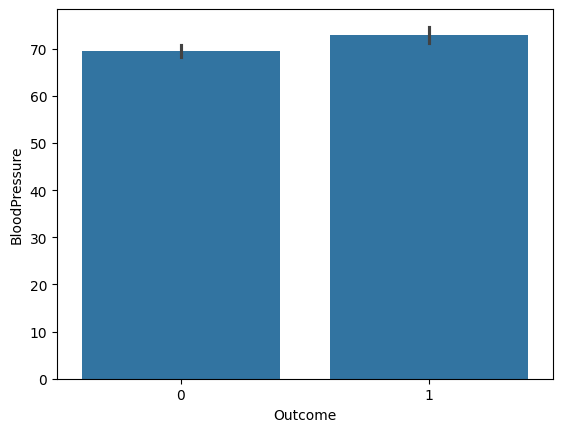

Outcome
0    13.549210
1    15.115805
Name: BloodPressure, dtype: float64


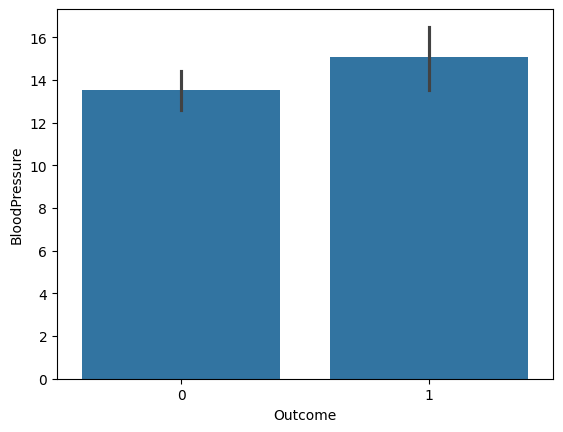

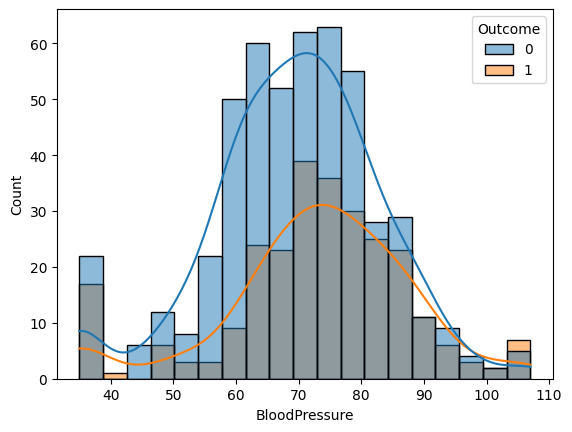

Reject H0


In [40]:
gr=df.groupby("Outcome")["BloodPressure"].mean()
print(gr)
sns.barplot(x=df["Outcome"],y=df["BloodPressure"],estimator=np.mean)
plt.show()
gr1=df.groupby("Outcome")["BloodPressure"].std()
print(gr1)
sns.barplot(x=df["Outcome"],y=df["BloodPressure"],estimator=np.std)
plt.show()
sns.histplot(x=df["BloodPressure"],hue=df["Outcome"],data=df,kde=True)
plt.show()
die_age=df["BloodPressure"][df["Outcome"]==1]
nondie_age=df["BloodPressure"][df["Outcome"]==0]
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_age,nondie_age)
alpha=0.05
if p<alpha:
    print("Reject H0")
else:
    print("Accept H0")

Glucose : Reject H0
BloodPressure : Reject H0
SkinThickness : Reject H0
Insulin : Reject H0
BMI : Reject H0
DiabetesPedigreeFunction : Reject H0


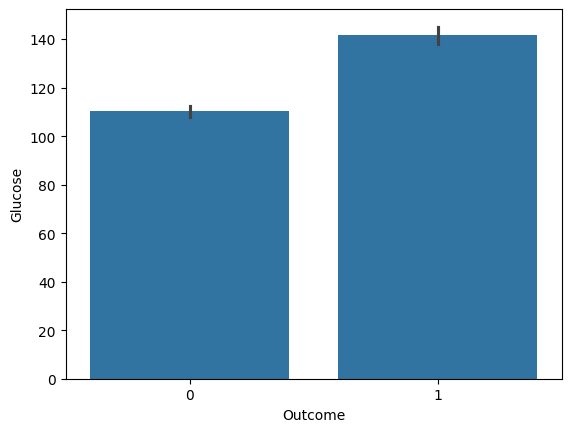

Average Glucose by Outcome:
 Outcome
0    110.202750
1    141.534515
Name: Glucose, dtype: float64


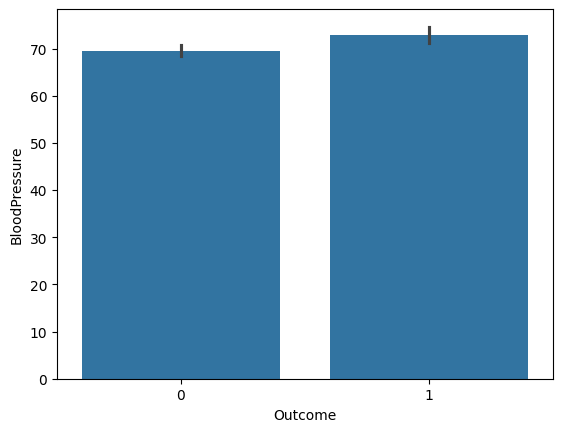

Average BloodPressure by Outcome:
 Outcome
0    69.508000
1    72.880597
Name: BloodPressure, dtype: float64


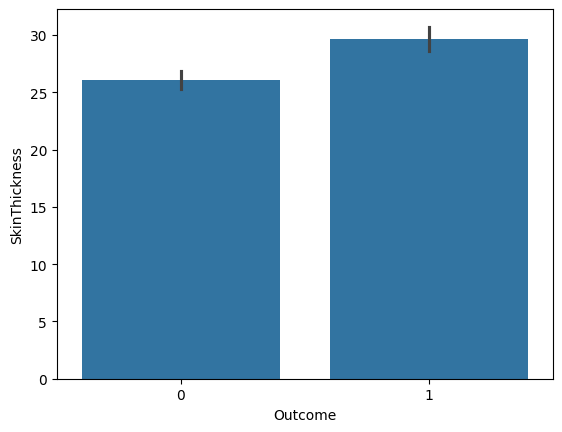

Average SkinThickness by Outcome:
 Outcome
0    26.058000
1    29.645522
Name: SkinThickness, dtype: float64


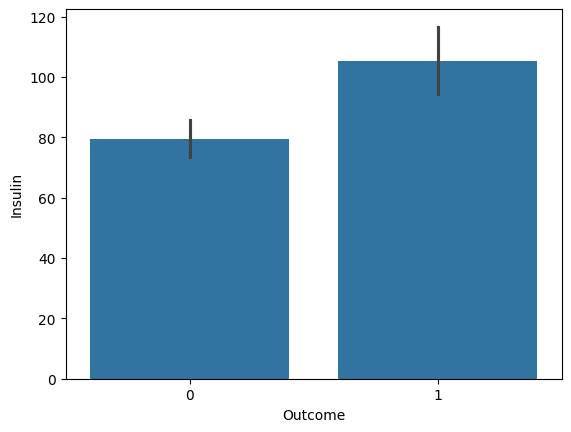

Average Insulin by Outcome:
 Outcome
0     79.509750
1    105.288713
Name: Insulin, dtype: float64


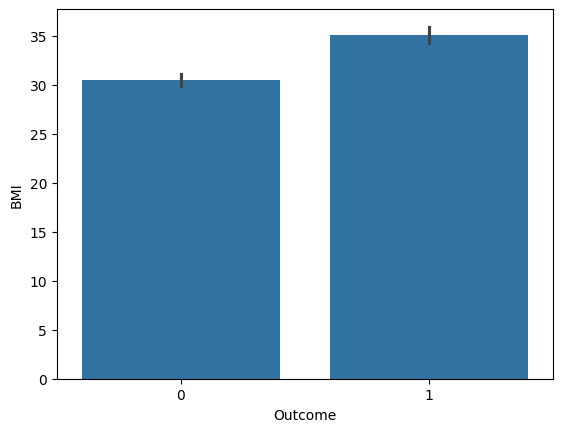

Average BMI by Outcome:
 Outcome
0    30.527500
1    35.105597
Name: BMI, dtype: float64


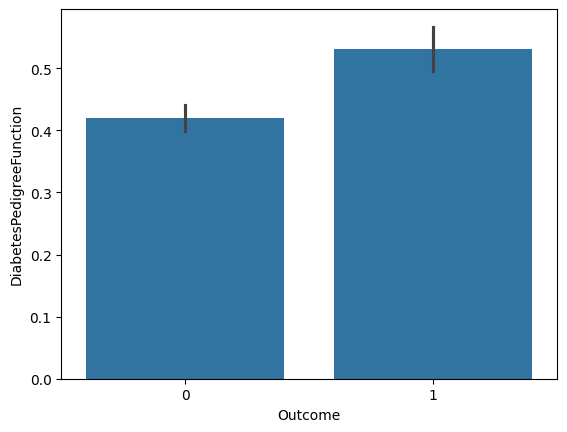

Average DiabetesPedigreeFunction by Outcome:
 Outcome
0    0.420264
1    0.531022
Name: DiabetesPedigreeFunction, dtype: float64


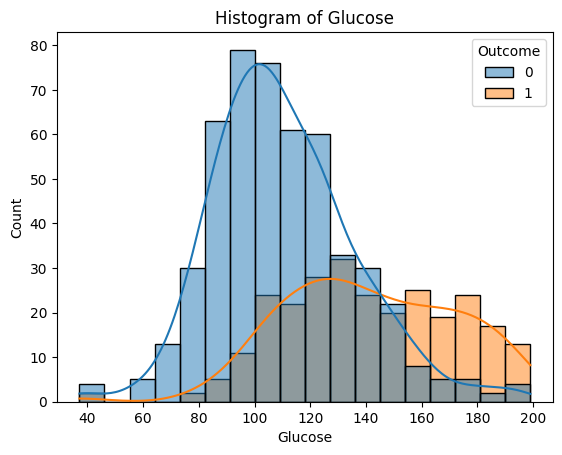

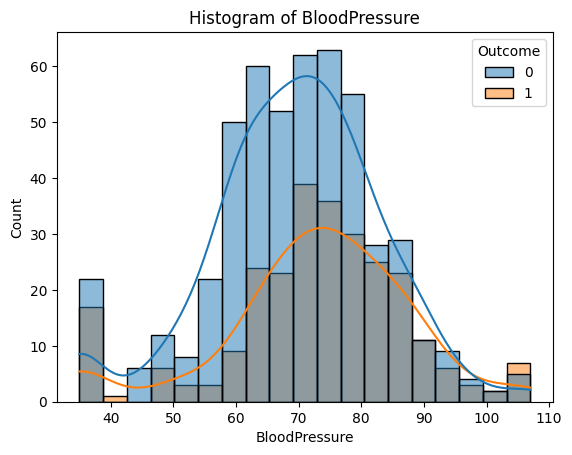

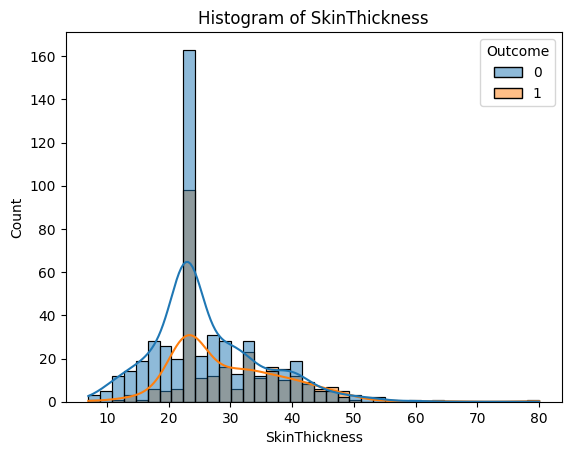

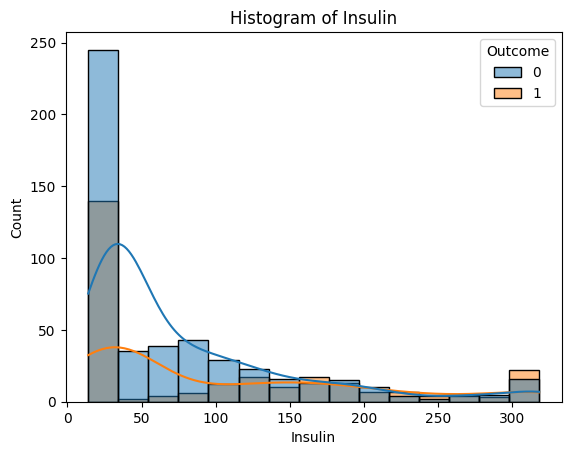

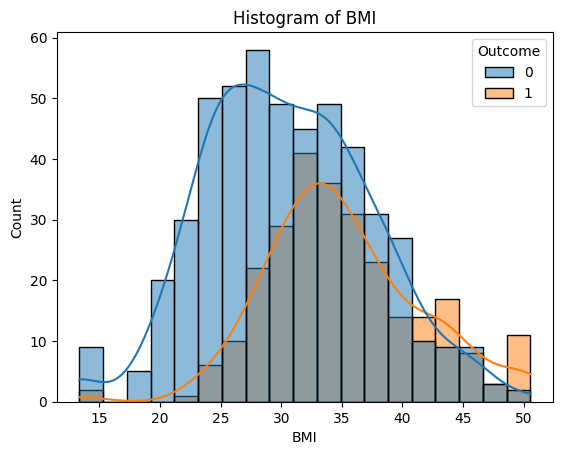

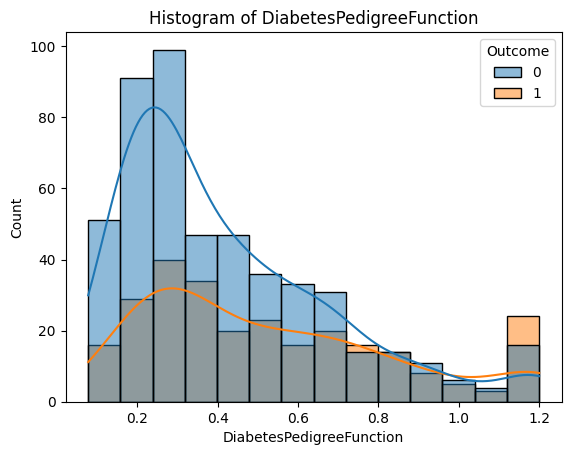

In [41]:
columns= [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]
for col in columns:
    die_cols=df[col][df["Outcome"]==1]
    non_die_cols=df[col][df["Outcome"]==0]
    stat ,p=ttest_ind(die_cols,non_die_cols)
    alpha =0.05
    if p<alpha:
        print(col,": Reject H0")
    else:
        print(col,": Accept H0")


for col in columns:
    sns.barplot(data=df, x='Outcome', y=col, estimator=np.mean)
    plt.show()
    avg_of_col = df.groupby('Outcome')[col].mean()
    print(f"Average {col} by Outcome:\n", avg_of_col)

for col in columns:
    sns.histplot(x=col,hue='Outcome',data=df,kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

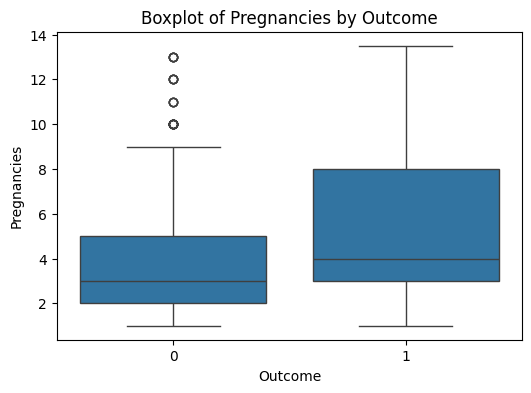

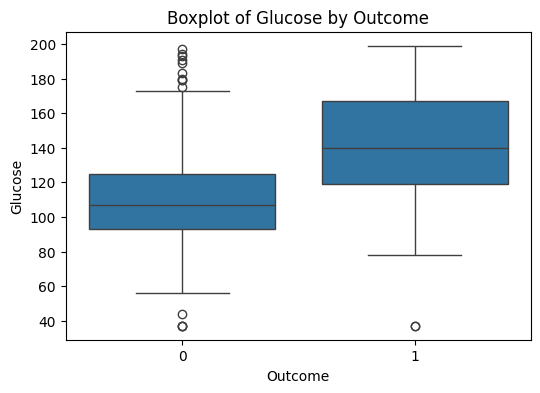

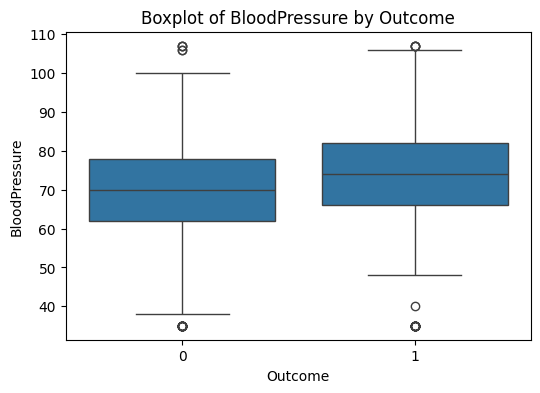

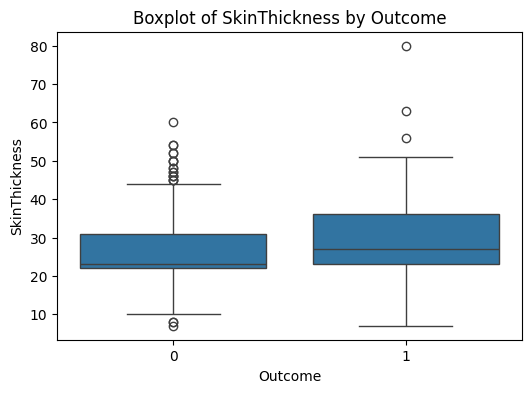

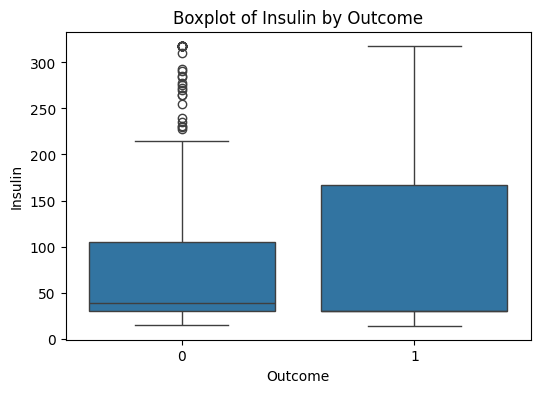

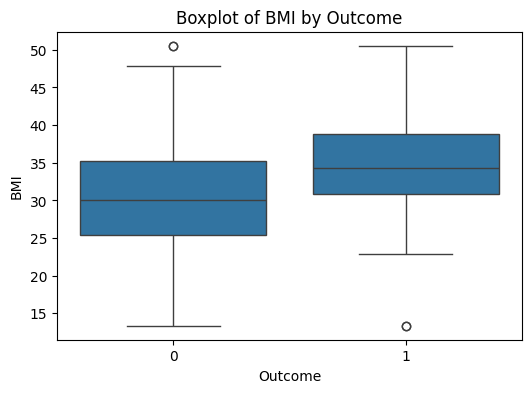

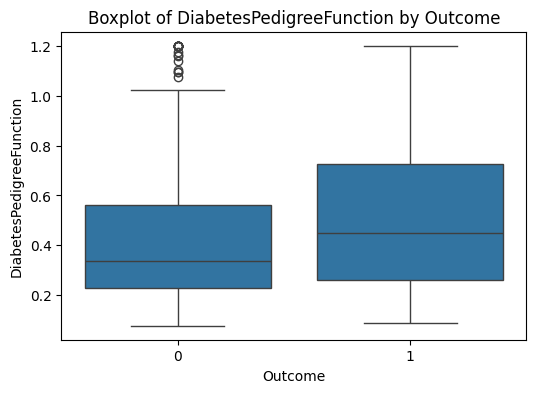

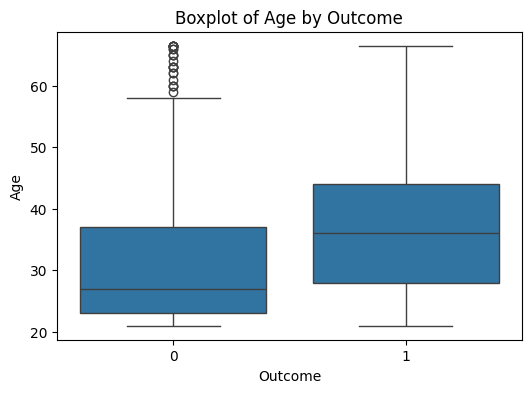

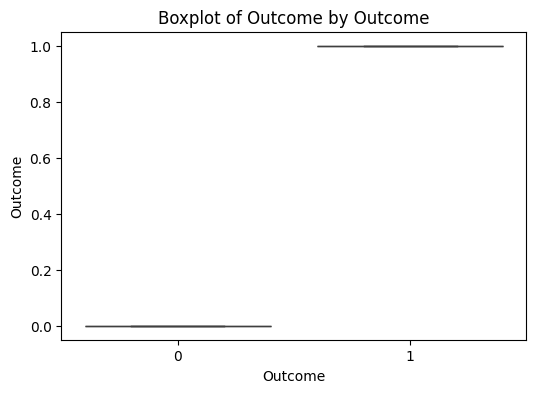

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Outcome', y=col)
    plt.title(f"Boxplot of {col} by Outcome")
    plt.xlabel("Outcome")
    plt.ylabel(col)
    plt.show()


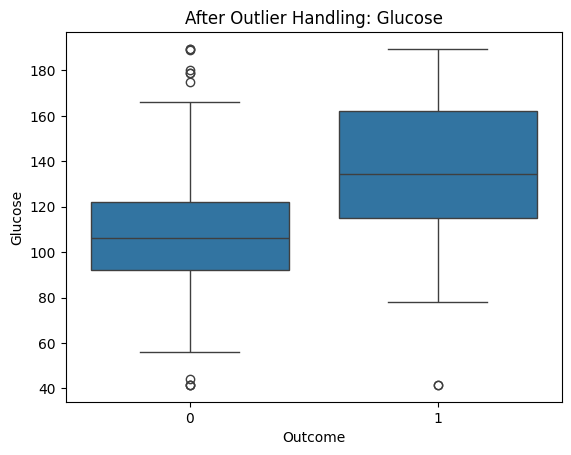

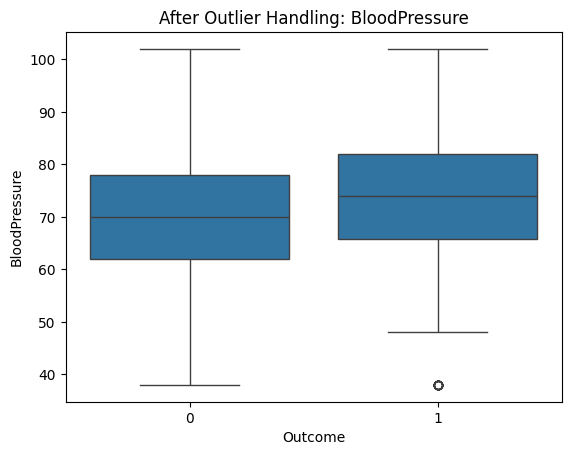

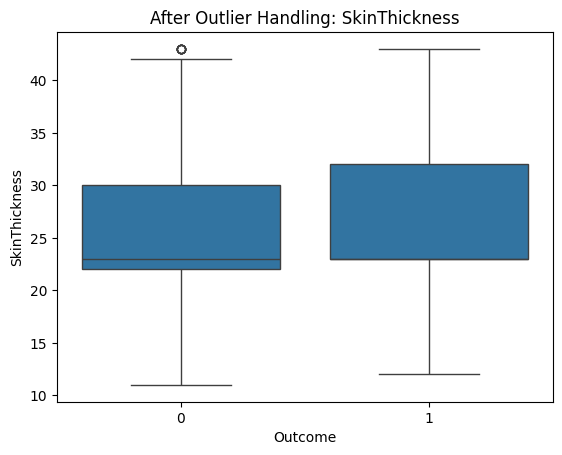

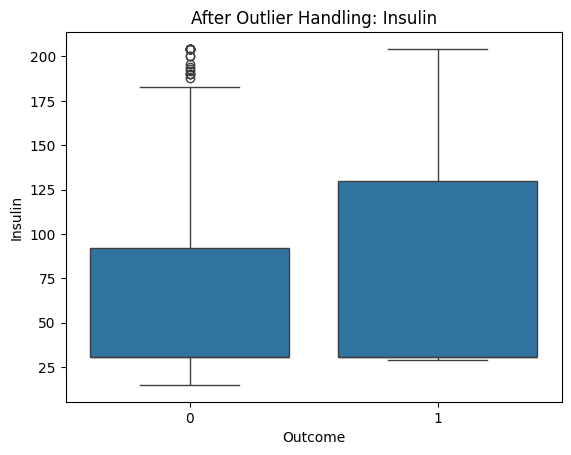

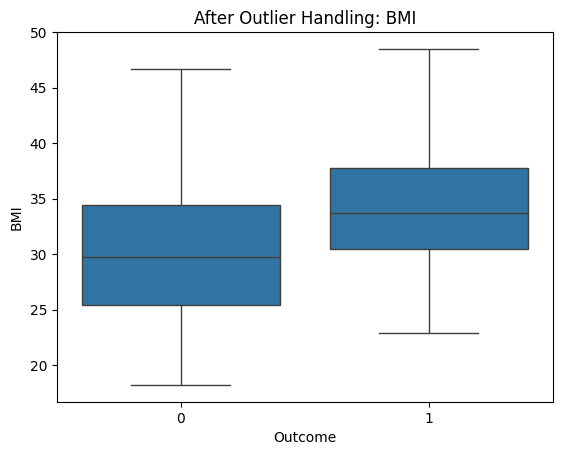

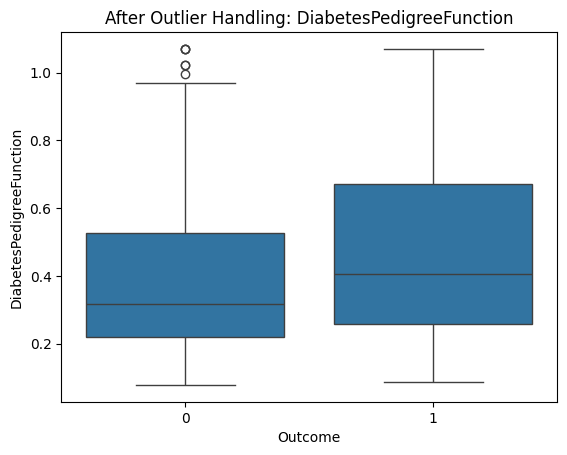

In [43]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in columns:
    lower, upper = detect_outliers_iqr(df, col)
    df = df[(df[col] >= lower) & (df[col] <= upper)]


for col in columns:
    lower, upper = detect_outliers_iqr(df, col)
    df[col] = df[col].clip(lower, upper)


from scipy.stats import zscore

for col in columns:
    df = df[(abs(zscore(df[col])) < 3)]

for col in columns:
    sns.boxplot(data=df, x='Outcome', y=col)
    plt.title(f"After Outlier Handling: {col}")
    plt.show()


In [44]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [45]:
from sklearn.preprocessing import MinMaxScaler
X = df.drop('Outcome', axis=1)
y = df['Outcome']

zero_cols = X.columns[(X == 0).any()]
X[zero_cols] = X[zero_cols].replace(0, X[zero_cols].median())

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
print("confusion_matrix \n",confusion_matrix(y_train,y_train_pred))
print("Accuracy for train :", accuracy_score(y_train, y_train_pred))

y_test_pred = model.predict(X_test)
print("confusion_matrix \n",confusion_matrix(y_test,y_test_pred))
print("Accuracy for test:", accuracy_score(y_test, y_test_pred))





confusion_matrix 
 [[322  26]
 [ 75  85]]
Accuracy for train : 0.8011811023622047
confusion_matrix 
 [[75 13]
 [23 17]]
Accuracy for test: 0.71875


In [46]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt

In [49]:
X_test.shape

(128, 8)

In [56]:
y_prob=model.predict_proba(X_test)[:,1]
y_prob

array([0.75437885, 0.32978108, 0.21768006, 0.46394722, 0.75160378,
       0.14603719, 0.37004522, 0.76311985, 0.78965052, 0.33240026,
       0.08330651, 0.1941161 , 0.25964151, 0.20301793, 0.60605222,
       0.08757207, 0.17571266, 0.70447082, 0.09892461, 0.04125186,
       0.24905605, 0.35420517, 0.17301167, 0.08165913, 0.42193893,
       0.6159486 , 0.69465418, 0.32336582, 0.82880213, 0.02235477,
       0.30762411, 0.01171745, 0.14226734, 0.32164631, 0.33781272,
       0.53327106, 0.03865172, 0.7613146 , 0.13485926, 0.05623461,
       0.48083582, 0.23960625, 0.07251892, 0.40219885, 0.33690629,
       0.05657972, 0.31069901, 0.24695482, 0.64198113, 0.17520753,
       0.21607566, 0.35172084, 0.08384415, 0.38273026, 0.08397405,
       0.06653807, 0.69540288, 0.54822849, 0.11711765, 0.15865868,
       0.25096534, 0.7432128 , 0.08895365, 0.06225007, 0.07405017,
       0.32195307, 0.14487559, 0.34099774, 0.31360917, 0.11542868,
       0.81091641, 0.12075176, 0.84566831, 0.39162538, 0.55636

In [57]:
fpr,tpr,thresholds= roc_curve(y_test,y_prob)

AUC Score: 0.7542613636363635


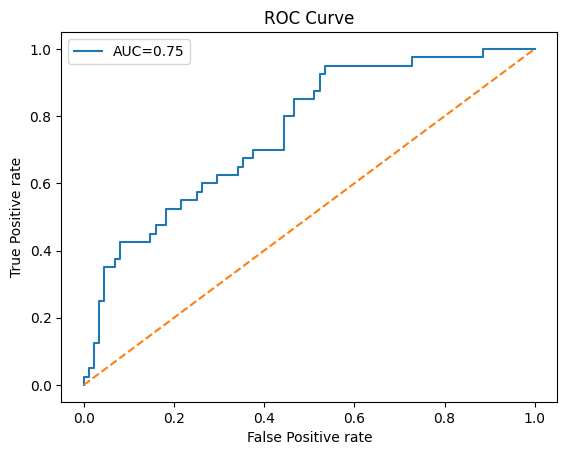

In [58]:
auc_Score=roc_auc_score(y_test,y_prob)
print("AUC Score:",auc_Score)


plt.figure()
plt.plot(fpr,tpr,label=f"AUC={auc_Score:.2f}")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.title("ROC Curve")
plt.legend()
plt.show()